# Leaf-Primary and Combined Transfer Summary

## tl;dr

This notebook summarizes the current Wolffia transfer-model refinement. The project now uses an ortholog-aware hierarchy:

- **Ortholog mapping** defines the 340 Arabidopsis genes that can be defensibly transferred to Wolffia.
- **Root-derived model** is retained as a conservative benchmark.
- **Leaf-primary model** is now the main Wolffia-relevant biological layer because Wolffia is a reduced photosynthetic plant body.
- **Combined application script** applies both views to future Wolffia matrices and preserves ambiguous/review-required outcomes.

The important caveat: current accuracy/recovery values are Arabidopsis reference benchmarks, not true Wolffia accuracy.

## Context & Methods

### Key assumptions

- The future Wolffia input will be a normalized, `log1p`-transformed `.h5ad` file.
- Cross-species model features must pass Arabidopsis-to-Wolffia ortholog filtering.
- The leaf model receives primary biological weight; the root model is secondary benchmark evidence.
- A label is only accepted when both model components agree and meet the confidence threshold.

### Source artifacts

This notebook reads current local summary artifacts generated by the project scripts:

- `results/orthology/orthology_summary.json`
- `results/root_reference_consensus_ortholog_restricted/benchmark_summary.json`
- `results/leaf_primary_ortholog_model/leaf_primary_model_summary.json`
- `results/combined_wolffia_application/combined_application_summary.json`
- `data/metadata/gse161332_pscb_cluster_annotation_map.csv`

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
plt.style.use("default")
PROJECT_ROOT = Path("..").resolve()

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, encoding="utf-8") as handle:
        return json.load(handle)

orthology = read_json("results/orthology/orthology_summary.json")
root_summary = read_json("results/root_reference_consensus_ortholog_restricted/benchmark_summary.json")
leaf_summary = read_json("results/leaf_primary_ortholog_model/leaf_primary_model_summary.json")
combined_summary = read_json("results/combined_wolffia_application/combined_application_summary.json")
cluster_map = pd.read_csv(PROJECT_ROOT / "data/metadata/gse161332_pscb_cluster_annotation_map.csv")

print("Loaded summaries:")
print("- orthology", orthology["method"])
print("- root benchmark cells", root_summary["n_root_cells"])
print("- leaf labeled cells", leaf_summary["n_training_cells_after_filtering"])
print("- combined smoke-test cells", combined_summary["n_cells"])

Loaded summaries:
- orthology gene-level reciprocal best protein hits after longest-isoform selection
- root benchmark cells 4727
- leaf labeled cells 4587
- combined smoke-test cells 64


## Data

### 1. Ortholog filtering

The ortholog layer is the species bridge. It does not depend on root vs leaf tissue; it maps Arabidopsis genes to Wolffia genes.

In [2]:
ortholog_counts = (
    pd.Series(orthology["model_feature_confidence_counts"], name="n_genes")
    .rename_axis("mapping_confidence")
    .reset_index()
)
ortholog_counts["mapping_confidence"] = pd.Categorical(
    ortholog_counts["mapping_confidence"],
    categories=["high", "medium", "low", "unmapped"],
    ordered=True,
)
ortholog_counts = ortholog_counts.sort_values("mapping_confidence")
ortholog_counts

,mapping_confidence,n_genes
2,high,217
3,medium,123
0,low,874
1,unmapped,786


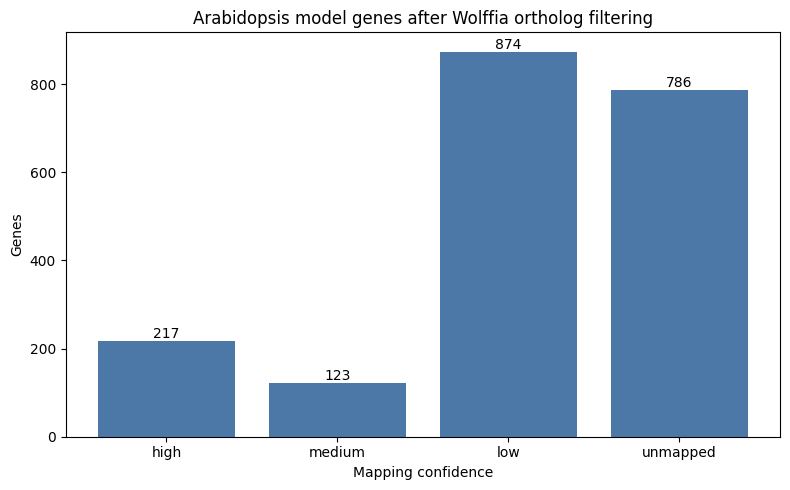

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ortholog_counts["mapping_confidence"].astype(str), ortholog_counts["n_genes"], color="#4C78A8")
ax.set_title("Arabidopsis model genes after Wolffia ortholog filtering")
ax.set_xlabel("Mapping confidence")
ax.set_ylabel("Genes")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()

### 2. Leaf published-cluster labels

The refined leaf model uses PSCB/Kim et al. cluster labels collapsed into broad project programs where metadata are available.

In [4]:
cluster_map[["cluster_id", "published_cluster_label", "broad_program", "interpretation_notes"]].head(20)

,cluster_id,published_cluster_label,broad_program,interpretation_notes
0,0,unassigned,ambiguous,Cluster not assigned to a known cell type in t...
1,1,mesophyll,photosynthetic_or_assimilation,One of the mesophyll clusters listed in the pu...
2,2,mesophyll_spongy_candidate,photosynthetic_or_assimilation,Mesophyll cluster; FIL/YAB1 enrichment suggest...
3,3,mesophyll,photosynthetic_or_assimilation,One of the mesophyll clusters listed in the pu...
4,4,bundle_sheath_xylem_mixed,vascular_like_or_transport,Cluster contains bundle sheath and xylem-relat...
5,5,mesophyll,photosynthetic_or_assimilation,One of the mesophyll clusters listed in the pu...
6,6,mesophyll_rrna_enriched,photosynthetic_or_assimilation,Mesophyll cluster enriched for rRNA; publicati...
7,7,mesophyll_spongy_candidate,photosynthetic_or_assimilation,Mesophyll cluster; FIL/YAB1 enrichment suggest...
8,8,mesophyll,photosynthetic_or_assimilation,One of the mesophyll clusters listed in the pu...
9,9,mesophyll_rrna_enriched,photosynthetic_or_assimilation,Mesophyll cluster enriched for rRNA; publicati...


In [5]:
leaf_label_counts = (
    pd.Series(leaf_summary["training_label_counts_after_filtering"], name="n_cells")
    .rename_axis("broad_program")
    .reset_index()
    .sort_values("n_cells", ascending=False)
)
leaf_label_counts

,broad_program,n_cells
0,photosynthetic_or_assimilation,3527
1,vascular_like_or_transport,820
2,epidermal_or_surface_identity,177
3,transport_interface_or_water_balance,63


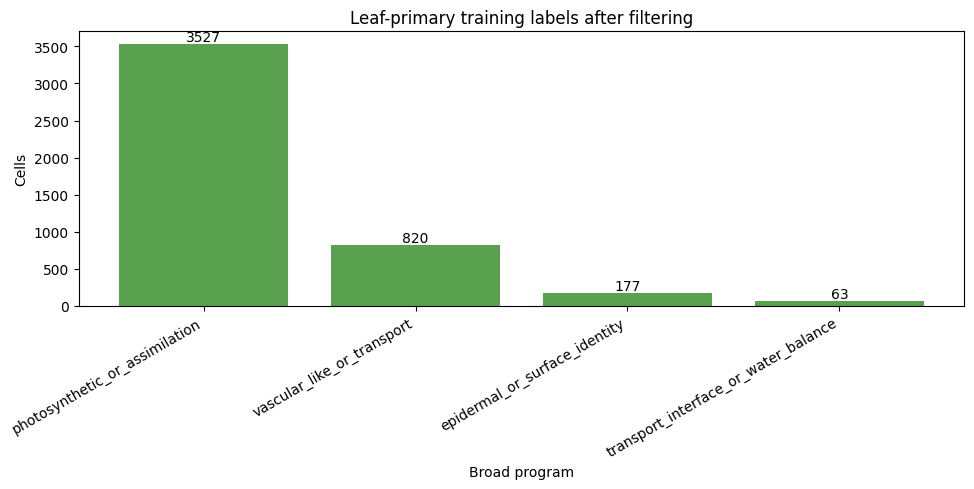

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(leaf_label_counts["broad_program"], leaf_label_counts["n_cells"], color="#59A14F")
ax.set_title("Leaf-primary training labels after filtering")
ax.set_xlabel("Broad program")
ax.set_ylabel("Cells")
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_ha("right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()

## Results

### 3. Root vs leaf model comparison

The root and leaf benchmarks are not a direct competition because they use different reference contexts. The comparison is meant to clarify model roles.

In [7]:
model_comparison = pd.DataFrame([
    {
        "model_layer": "v1_root_benchmark",
        "role": "secondary benchmark",
        "reference": "Arabidopsis root",
        "label_source": "marker-derived root pseudo-labels",
        "training_or_reference_cells": root_summary["n_root_cells"],
        "transfer_features": root_summary["n_selected_genes"],
        "consensus_acceptance_rate": root_summary["consensus_acceptance_rate"],
        "selective_recovery": 0.953,
    },
    {
        "model_layer": "v2_leaf_primary",
        "role": "primary Wolffia-relevant layer",
        "reference": "Arabidopsis leaf",
        "label_source": leaf_summary["label_status"],
        "training_or_reference_cells": leaf_summary["n_training_cells_after_filtering"],
        "transfer_features": leaf_summary["n_present_transfer_features"],
        "consensus_acceptance_rate": leaf_summary["consensus_acceptance_rate"],
        "selective_recovery": leaf_summary["consensus_selective_accuracy"],
    },
])
model_comparison

,model_layer,role,reference,label_source,training_or_reference_cells,transfer_features,consensus_acceptance_rate,selective_recovery
0,v1_root_benchmark,secondary benchmark,Arabidopsis root,marker-derived root pseudo-labels,4727,340,0.264748,0.953000
1,v2_leaf_primary,primary Wolffia-relevant layer,Arabidopsis leaf,Published PSCB/Kim et al. cluster labels colla...,4587,340,0.433399,0.936117


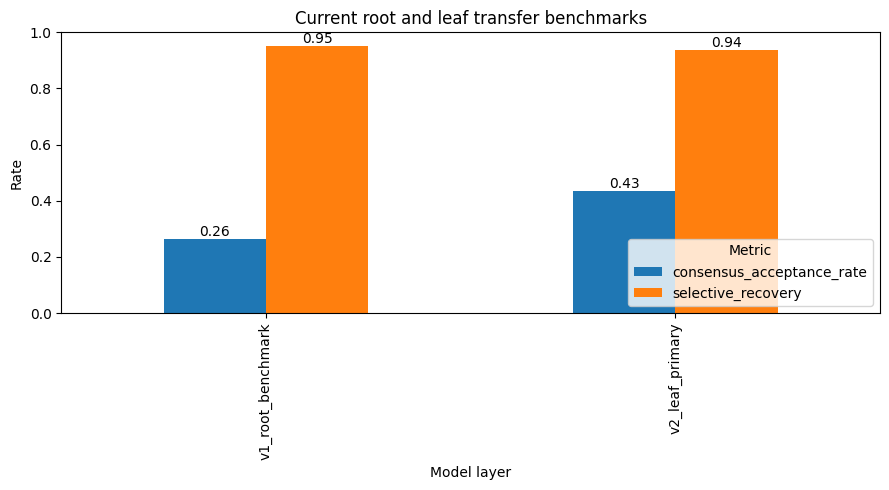

In [8]:
plot_data = model_comparison.melt(
    id_vars="model_layer",
    value_vars=["consensus_acceptance_rate", "selective_recovery"],
    var_name="metric",
    value_name="value",
)
fig, ax = plt.subplots(figsize=(9, 5))
pivot_plot = plot_data.pivot(index="model_layer", columns="metric", values="value")
pivot_plot.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("Current root and leaf transfer benchmarks")
ax.set_xlabel("Model layer")
ax.set_ylabel("Rate")
ax.legend(title="Metric", loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")
plt.tight_layout()

### 4. Combined application smoke test

The combined script was tested on random synthetic Wolffia-like input. Returning all ambiguous labels is expected and desirable for meaningless input: the model should not force confident labels when evidence is weak.

In [9]:
combined_summary

{'input': 'synthetic_smoke_test',
 'n_cells': 64,
 'n_transfer_features': 340,
 'feature_coverage': 1.0,
 'min_model_confidence': 0.6,
 'min_feature_coverage': 0.8,
 'leaf_acceptance_rate': 0.0,
 'root_acceptance_rate': 0.0,
 'final_label_counts': {'ambiguous': 64},
 'final_status_counts': {'both_models_ambiguous': 64},
 'interpretation_warning': 'Final labels are provisional transfer predictions. Biological annotation still requires marker-module, cluster-level, QC, and dataset-reproducibility support.'}

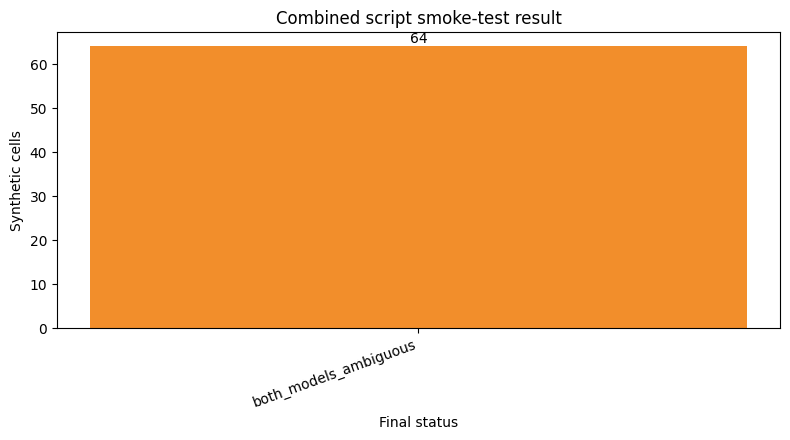

In [10]:
status_counts = (
    pd.Series(combined_summary["final_status_counts"], name="n_cells")
    .rename_axis("final_status")
    .reset_index()
)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(status_counts["final_status"], status_counts["n_cells"], color="#F28E2B")
ax.set_title("Combined script smoke-test result")
ax.set_xlabel("Final status")
ax.set_ylabel("Synthetic cells")
ax.tick_params(axis="x", rotation=20)
for label in ax.get_xticklabels():
    label.set_ha("right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()

## Takeaways

1. **Ortholog filtering is the transfer gate.** The model starts from 2,000 Arabidopsis genes, but only 340 high/medium-confidence Arabidopsis-to-Wolffia mappings are used for strict transfer.
2. **Root is now a benchmark, not the main biological model.** It remains valuable because it stress-tests the conservative rejection rule.
3. **Leaf is the primary biological direction.** The leaf-primary model uses PSCB/Kim et al. leaf cluster labels and captures photosynthetic/aerial programs that are more relevant to Wolffia.
4. **The combined script is application-ready.** It can apply leaf and root views to a future Wolffia `.h5ad` and preserve ambiguous or review-required outputs.
5. **True Wolffia accuracy still requires Wolffia labels or validation evidence.** Until then, the outputs should be described as transfer predictions and marker-supported hypotheses.